# Trajectory Taxonomy: ScienceWorld, ALFWorld, WebShop

**Goal:** understand *what kinds of trajectories exist* in the three downstream
environments the AOMT models are evaluated on — ScienceWorld, ALFWorld, and WebShop.

**Data source:** the Hugging Face dataset
[`Joshyxwa/cp2107-textworld-trajectories`](https://huggingface.co/datasets/Joshyxwa/cp2107-textworld-trajectories),
which ships per-environment `train/validation/test.jsonl` under `scienceworld/`,
`alfworld/`, and `webshop/`. The notebook **downloads these itself** into
`data/<env>/` (Section 1). The repo is **gated**, so you must be authenticated —
set `HF_TOKEN` or run `huggingface-cli login` once (instructions in Section 1).

This notebook builds a **portable trajectory taxonomy** (a shared schema + slice
framework that works across all three environments) and characterizes each along
those axes: goal families, objective types, trajectory length, interaction patterns,
observation density, and action vocabulary. Taxonomy definitions are imported from
`scripts/transform/taxonomy.py` so nothing drifts from the existing audit artifacts.

## 0. Setup

In [27]:
# auto-reload edited scripts/**/*.py without restarting the kernel
%load_ext autoreload
%autoreload 2

import sys, os, json, shutil, re
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# Path bootstrap (unavoidable): `import scripts...` needs the repo root on sys.path, and we
# can't import from the package until it's there — so walk up from cwd for the scripts/
# package once, here. Everything else (ROOT, find_repo_root, ...) then comes from the package.
sys.path.insert(0, str(next(p for p in (Path.cwd(), *Path.cwd().parents)
                            if (p / "scripts" / "__init__.py").is_file())))

# taxonomy classifiers live in scripts/transform/taxonomy.py; reused here so the notebook
# labels match artifacts/trajectory_features.csv exactly. ROOT is authoritative from the
# package (derived from its own location), and find_repo_root now lives in scripts/utils/common.py.
from scripts.utils.common import ROOT, find_repo_root
DATA, ARTIFACTS, SCRIPTS = ROOT / "data", ROOT / "artifacts", ROOT / "scripts"
print("repo root:", ROOT)

from scripts.transform import taxonomy as ad
print("imported taxonomy from:", ad.__file__)

# One theme for every figure below (scripts/viz/plot_theme.py): shared surface, ink, grid
# and fonts, plus a fixed hue per environment, so a colour means the same thing in
# every chart in the notebook. Palettes are validated for colourblind separation and
# contrast, not eyeballed.
from scripts.viz import plot_theme as pt
pt.apply_theme()
print("theme colours:", pt.ENV_COLORS)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
repo root: C:\code\AOMT
imported taxonomy from: c:\code\AOMT\scripts\transform\taxonomy.py
theme colours: {'scienceworld': '#2a78d6', 'alfworld': '#eb6834', 'webshop': '#4a3aa7'}


## 1. Fetch the dataset from Hugging Face

The dataset is **gated** — authenticate once, then this cell pulls the 9 files
(`{scienceworld,alfworld,webshop}/{train,validation,test}.jsonl`) into `data/<env>/`.
Already-present files are skipped (pass `force=True` to `download_hf_dataset` to re-pull).

**Authenticate (any one works — the cell tries them in this order):**
1. **Inline** — paste a Read token into `HF_TOKEN_OVERRIDE` in the cell below and re-run. Surest option: it guarantees *this kernel process* has the token (leave it `""` before committing).
2. **Env var** — `setx HF_TOKEN "hf_xxx"` (persists) or `$env:HF_TOKEN="hf_xxx"` (session), then **restart the kernel** so it inherits the variable.
3. **Cached login** — run `huggingface-cli login` (or `hf auth login`) once; the cell finds the stored token automatically.

> The token must be reachable by the **exact process running this notebook** — a value set in a different terminal than the one that launched the kernel won't be visible. Create a token at https://huggingface.co/settings/tokens (Read scope), using an account that has accepted the dataset's access terms.

In [28]:
# The HF fetch (extract step) lives in scripts/transform/hf_download.py, so this cell is
# just the call + a print summary. Already-present files are skipped (force=True re-pulls).
from scripts.transform.hf_download import download_hf_dataset, REPO_ENVS, SPLITS

got, failed, token_source = download_hf_dataset(DATA, ROOT)
n_expected = len(REPO_ENVS) * len(SPLITS)
print(f"token source: {token_source}")
print(f"available locally: {len(got)}/{n_expected} files")
for g in got:
    print("  ", g)
if failed:
    print("\ncould NOT fetch the following — the repo is gated:")
    for name, err in failed:
        print(f"   {name}  ({err})")
    print("\nThis kernel process has no valid token. Fix ONE of:")
    print("  - set HF_TOKEN in the shell that launched this kernel, then restart the kernel; or")
    print("  - run `huggingface-cli login` (persists a cached token resolve_token will find).")
    print("Use an account that has accepted the dataset's access terms.")

token source: env HF_TOKEN
available locally: 9/9 files
   data/scienceworld/train.jsonl
   data/scienceworld/validation.jsonl
   data/scienceworld/test.jsonl
   data/alfworld/train.jsonl
   data/alfworld/validation.jsonl
   data/alfworld/test.jsonl
   data/webshop/train.jsonl
   data/webshop/validation.jsonl
   data/webshop/test.jsonl


## 2. Imported helpers (loaders, taxonomy, profiler)

The notebook's machinery lives in the `scripts/` package (`transform/` · `viz/` · `utils/`),
split so that **data transforms carry no display side effects** and the **visualisation layer**
depends on them (never the reverse). The notebook itself defines no helper functions — the setup
cell only does a one-line path bootstrap, then imports everything (`ROOT`, `find_repo_root`, and
the helpers below) from the package:

- **Utils** (`scripts/utils/common.py`) — `ROOT` (repo root, from the package location) and
  `find_repo_root(start)` (walk-up fallback for odd working directories), plus io/hash helpers.
- **Transforms** (`scripts/transform/trajectory_analysis.py`) — pure, display-free, importable/testable:
  - *Loading* — `load_jsonl` / `canonical_record` / `load_env` map each environment's raw
    `blocks` (`Goal/Think/Action/Observation`) into one canonical record shape
    (`env, trajectory_id, split, goal, actions, observations, thinks, state_labels`). All
    three environments share the `blocks` schema.
  - *Enrichment* — `enrich()` turns a record into a taxonomy-labelled feature dict.
  - *Aggregation* — `build_features()` (records → feature DataFrame), `action_verb_counts()`,
    `objective_stats()`, and `summary_row()`. The notebook's own inline figures reuse these.
- **Taxonomy dispatch** (`scripts/transform/{taxonomy,env_taxonomy}.py`) — environment-aware
  goal-family / objective-type / action-verb classifiers. ScienceWorld reuses the audited
  classifiers; ALFWorld uses its exact `state_labels.task_type`; WebShop has search→click rules.
- **Visualisation** (`scripts/viz/trajectory_viz.py`) — `profile_env(env, records)` is the thin
  orchestrator (`build_features` → `plot_env_panels` → `objective_stats`, no chart code of its own);
  `plot_env_panels(df, records, env)` holds the 4-panel figure (goal-family / objective / length /
  top verbs); `render()` prints a single trajectory. This is the only layer that imports matplotlib.

In [29]:
'''
Transforms (loading / enrichment / aggregation) live in scripts/transform/trajectory_analysis.py;
the visualisation layer lives in scripts/viz/trajectory_viz.py. The split keeps the data
transforms importable and testable without a display, and lets this notebook's own inline figures
reuse the same feature tables. Both build on scripts/transform/{taxonomy,env_taxonomy}.py.

In the viz layer, profile_env is the thin orchestrator (build_features -> plot_env_panels ->
objective_stats) and plot_env_panels holds the chart logic — so profile_env carries no drawing
code of its own and the panels can be restyled without touching it.
'''
from scripts.transform import trajectory_analysis as ta
from scripts.viz import trajectory_viz as tv
from scripts.transform.trajectory_analysis import (
    load_jsonl, canonical_record, load_env, enrich, build_features, summary_row,
)
from scripts.viz.trajectory_viz import profile_env, render
from scripts.transform.env_taxonomy import action_verb   # used directly in the WebShop funnel cell below

## 3. Load all environments + coverage

In [30]:
ENVS = ["scienceworld", "alfworld", "webshop"]
loaded, coverage = {}, []
for env in ENVS:
    recs, present = load_env(env, DATA)
    loaded[env] = recs
    by_split = Counter(r["split"] for r in recs)
    schemas  = Counter(r["_schema"] for r in recs)
    coverage.append({
        "env": env, "present": present, "n_traj": len(recs),
        "train": by_split.get("train", 0), "validation": by_split.get("validation", 0),
        "test": by_split.get("test", 0),
        "schema": ",".join(sorted(schemas)) if schemas else "-",
    })
coverage_df = pd.DataFrame(coverage).set_index("env")
present_envs = [e for e in ENVS if coverage_df.loc[e, "present"]]
missing_envs = [e for e in ENVS if not coverage_df.loc[e, "present"]]
print("present:", present_envs, "| missing:", missing_envs or "none")
coverage_df

present: ['scienceworld', 'alfworld', 'webshop'] | missing: none


,present,n_traj,train,validation,test,schema
env,,,,,,
scienceworld,True,1483,1187,148,148,blocks
alfworld,True,7080,6574,251,255,blocks
webshop,True,3768,3014,377,377,blocks


## 4. ScienceWorld

Baseline environment: interactive science tasks (conductivity, find-a-thing,
temperature/melting-point measurement, lifespan comparison, plant growth).

[scienceworld]  1483 trajectories | schemas: {'blocks': 1483}


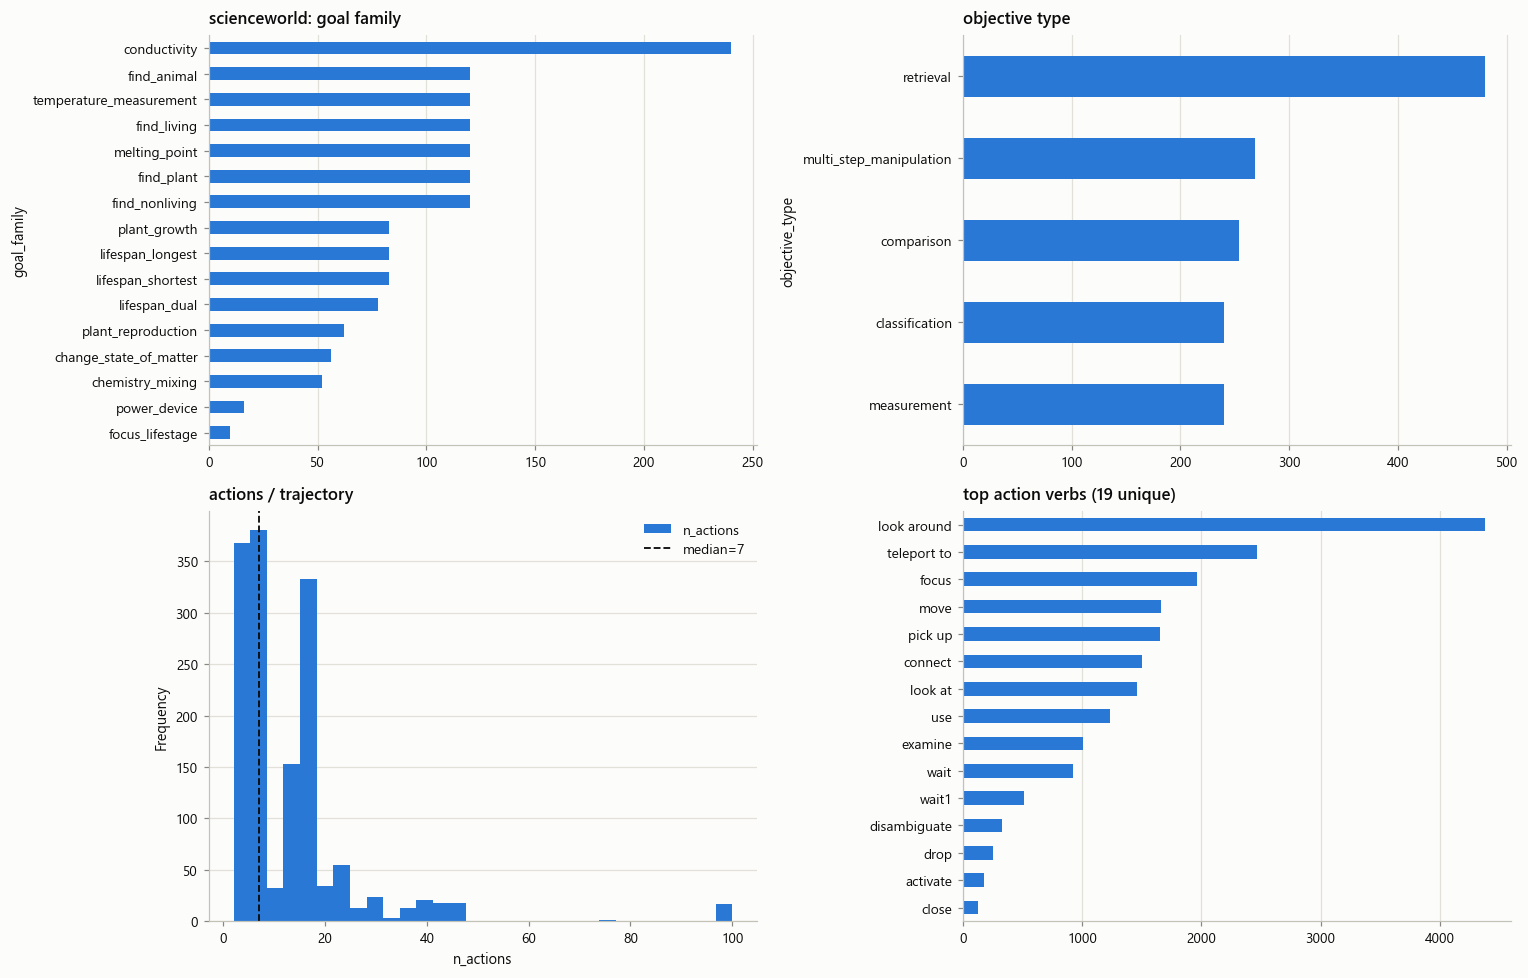

,count,median,mean,max
objective_type,,,,
classification,240,16.0,16.3,19
comparison,254,4.0,4.6,19
measurement,240,17.5,25.5,100
multi_step_manipulation,269,15.0,20.9,77
retrieval,480,7.0,6.4,7


In [31]:
sw = profile_env("scienceworld", loaded["scienceworld"])

In [32]:
sw.head(3)

,env,trajectory_id,split,goal,actions,observations,thinks,n_actions,n_observations,state_labels,_schema,goal_family,objective_type,source_format,goal_template_key,length_bin,interaction_pattern,ambiguity_pattern,avg_obs_chars,repeated_action_ratio
0,scienceworld,9_412,train,Your task is to determine if metal pot is elec...,"[look around, teleport to kitchen, pick up met...","[This room is called the foundry. In it, you s...",[I need to locate the metal pot to determine i...,17,16,{},blocks,conductivity,classification,None,your task is to determine if metal pot is elec...,medium,directed,none,131.437500,0.0625
1,scienceworld,11_0,train,"Your task is to find a(n) animal. First, focus...","[look around, teleport to outside, look around...","[This room is called the hallway. In it, you s...",[I need to find an animal as per the task desc...,7,6,{},blocks,find_animal,retrieval,None,"your task is to find a(n) animal<num> first, f...",short,directed,none,139.833333,0.0000
2,scienceworld,21_52,train,Your task is to find the animal with the longe...,"[look around, teleport to outside, look around...","[This room is called the kitchen. In it, you s...",[I need to find the animal with the longest li...,5,4,{},blocks,lifespan_dual,comparison,None,your task is to find the animal with the longe...,short,search_heavy,none,392.250000,0.0000


### 4.1 Interaction, ambiguity & observation density (ScienceWorld-specific)

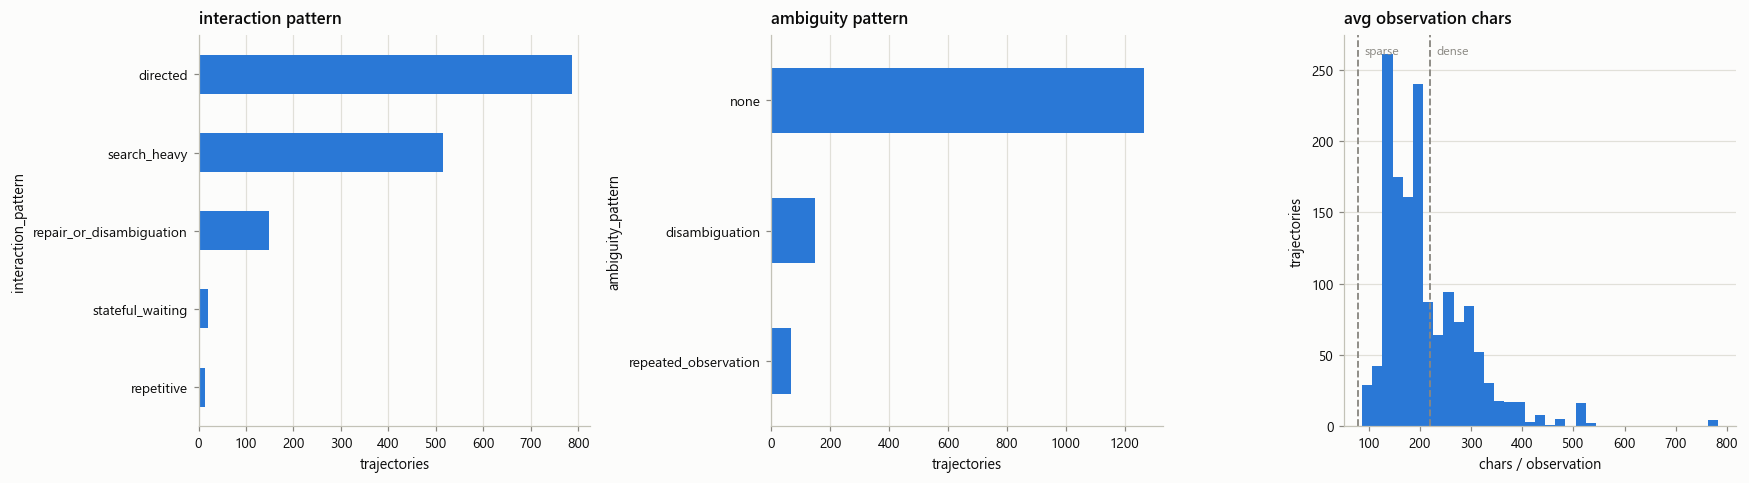

objective_type,classification,comparison,measurement,multi_step_manipulation,retrieval,All
goal_family,,,,,,
change_state_of_matter,0,0,0,56,0,56
chemistry_mixing,0,0,0,52,0,52
conductivity,240,0,0,0,0,240
find_animal,0,0,0,0,120,120
find_living,0,0,0,0,120,120
find_nonliving,0,0,0,0,120,120
find_plant,0,0,0,0,120,120
focus_lifestage,0,10,0,0,0,10
lifespan_dual,0,78,0,0,0,78


In [33]:
if sw is not None:
    C = pt.env_color("scienceworld")          # this whole section is ScienceWorld -> one hue
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    sw["interaction_pattern"].value_counts().plot.barh(ax=ax[0], color=C)
    ax[0].set_title("interaction pattern"); ax[0].set_xlabel("trajectories")
    ax[0].invert_yaxis(); pt.style_axes(ax[0], xgrid=True)

    sw["ambiguity_pattern"].value_counts().plot.barh(ax=ax[1], color=C)
    ax[1].set_title("ambiguity pattern"); ax[1].set_xlabel("trajectories")
    ax[1].invert_yaxis(); pt.style_axes(ax[1], xgrid=True)

    sw["avg_obs_chars"].plot.hist(bins=35, ax=ax[2], color=C)
    ax[2].set_title("avg observation chars"); ax[2].set_xlabel("chars / observation")
    ax[2].set_ylabel("trajectories"); pt.style_axes(ax[2])
    for x, name in [(80, "sparse"), (220, "dense")]:   # density-bin thresholds
        ax[2].axvline(x, color=pt.INK_MUTED, ls="--", lw=1.2)
        ax[2].annotate(name, xy=(x, 1), xycoords=("data", "axes fraction"),
                       xytext=(4, -12), textcoords="offset points",
                       color=pt.INK_MUTED, fontsize=8)

    plt.tight_layout(); plt.show()
    display(pd.crosstab(sw["goal_family"], sw["objective_type"], margins=True))

### 4.2 Example trajectories

In [34]:
if sw is not None:
    by_id = {r["trajectory_id"]: r for r in loaded["scienceworld"]}
    for fam in ["conductivity", "find_animal", "plant_growth"]:
        sub = sw[sw["goal_family"] == fam]
        if len(sub): render(by_id[sub.iloc[0]["trajectory_id"]])

[scienceworld] id=9_412  split=train  schema=blocks
GOAL: Your task is to determine if metal pot is electrically conductive. The metal pot is located around the kitchen. First, focus on the metal pot. If it is electrically conductive, place it in the blue box. If it is electrically nonconductive, place it in the orange box.
------------------------------------------------------------------------------------------
  ACTION: look around
  OBS   : This room is called the foundry. In it, you see: the agent a substance called air a blast furnace, which is turned off. The blast furnace door is open
  ACTION: teleport to kitchen
  OBS   : You teleport to the kitchen.
  ACTION: pick up metal pot containing nothing in kitchen
  OBS   : You move the metal pot to the inventory.
  ACTION: focus on metal pot containing nothing in inventory
  OBS   : You focus on the metal pot.
  ACTION: teleport to workshop
  OBS   : You teleport to the workshop.
  ACTION: drop metal pot
  OBS   : You move the meta

### 4.3 Leakage / duplication (audited local snapshot)
From `artifacts/trajectory_features.csv` (built by `scripts/audit_dataset.py` on the
local ScienceWorld snapshot). This is why split construction matters for D-Random vs D-Flex.

In [35]:
feat_path = ARTIFACTS / "trajectory_features.csv"
if feat_path.exists():
    feat = pd.read_csv(feat_path)
    val = feat[feat["source_split"] == "validation"]
    if len(val):
        print("Validation split-risk labels:"); print(val["current_split_risk"].value_counts().to_string())
        seen = val["current_split_risk"].isin(["template_seen", "exact_seen"]).mean()
        print(f"\ntemplate/exact-seen share of validation: {seen:.1%}")
    if "duplicate_cluster_id" in feat:
        cid = feat["duplicate_cluster_id"].fillna("")
        in_dup = ~cid.str.startswith("singleton_") & (cid != "")
        print(f"\ntrajectories in a real duplicate cluster: {int(in_dup.sum())} "
              f"across {cid[in_dup].nunique()} clusters (singletons excluded)")
else:
    print("trajectory_features.csv not found — run scripts/audit_dataset.py to regenerate.")

trajectory_features.csv not found — run scripts/audit_dataset.py to regenerate.


## 5. ALFWorld

Embodied household task completion (TextWorld + ALFRED). The **goal family is the
exact `state_labels.task_type`** (7 canonical ALFRED task types) rather than a
keyword guess. Actions are PDDL-style operators (`GotoLocation`, `PickupObject`,
`PutObject`, `ToggleObject`, `SliceObject`, `NoOp`). These are **offline plan traces**
— Think + Action dominate; the environment observation is essentially the initial
scene (≈1 observation per trajectory), so observation-density analysis doesn't apply
here the way it does for ScienceWorld.

[alfworld]  7080 trajectories | schemas: {'blocks': 7080}


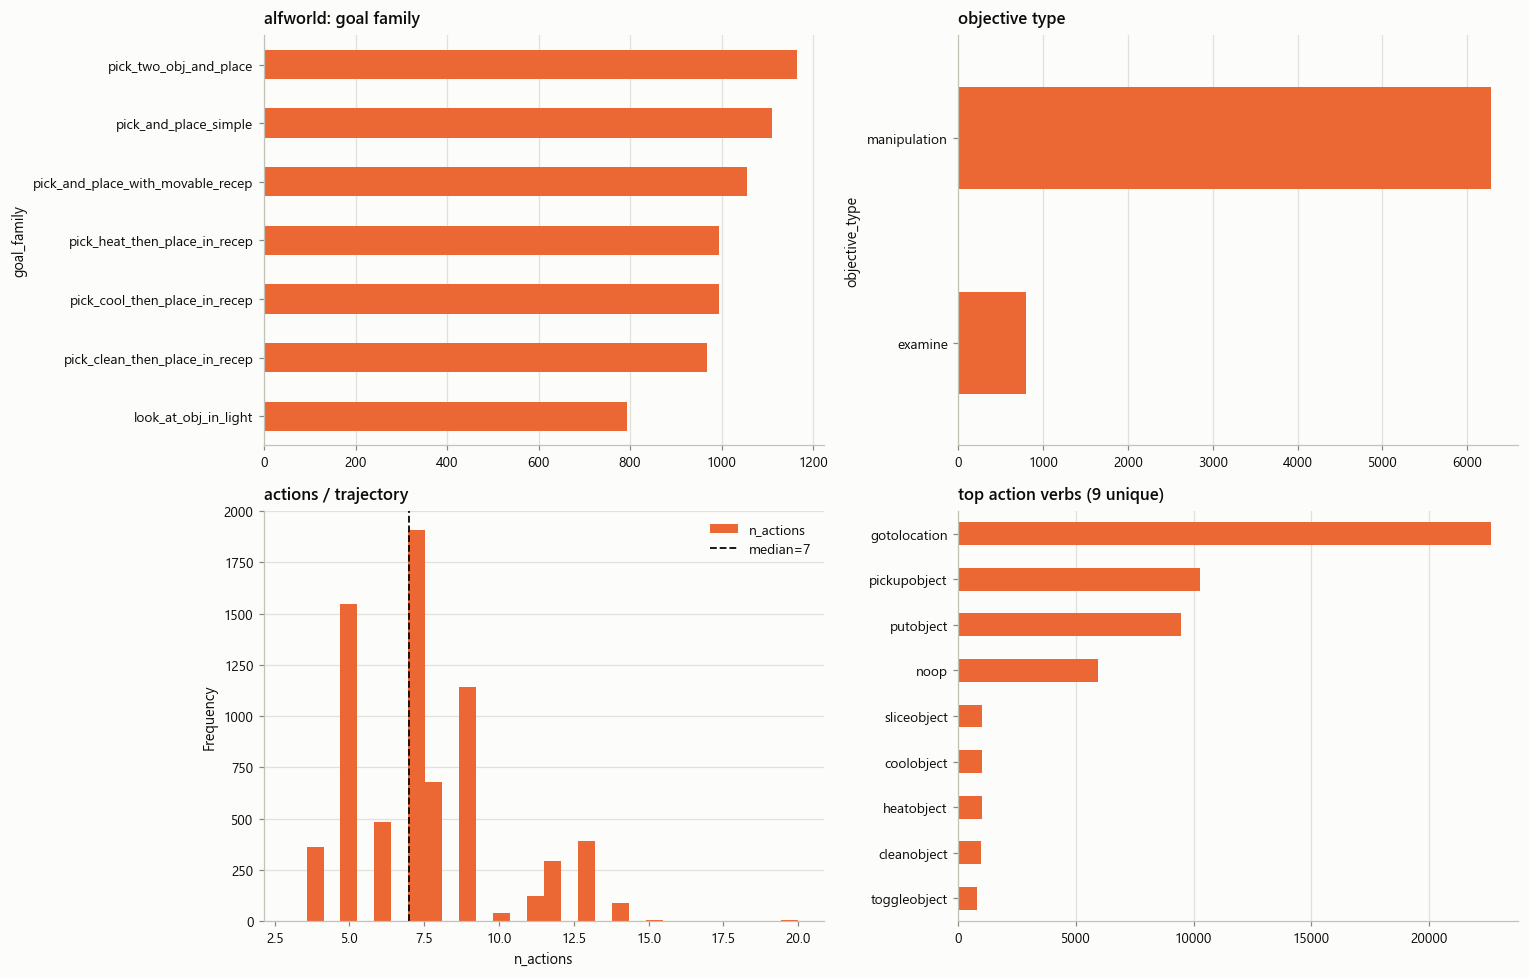

,count,median,mean,max
objective_type,,,,
examine,794,5.0,5.0,5
manipulation,6286,7.0,7.8,20


task_type source: state_labels (exact ALFRED labels)


,count,median,max
goal_family,,,
pick_two_obj_and_place,1165,9.0,20
pick_and_place_simple,1110,5.0,11
pick_and_place_with_movable_recep,1055,8.0,14
pick_heat_then_place_in_recep,994,7.0,15
pick_cool_then_place_in_recep,994,7.0,13
pick_clean_then_place_in_recep,968,7.0,15
look_at_obj_in_light,794,5.0,5


PDDL action operators: {'GotoLocation': 22671, 'PickupObject': 10286, 'PutObject': 9452, 'NoOp': 5931, 'SliceObject': 1001, 'CoolObject': 997, 'HeatObject': 994, 'CleanObject': 968, 'ToggleObject': 794}
share of precondition-stateful (clean/cool/heat) tasks: 41.8%
[alfworld] id=trial_T20190907_174127_043461  split=train  schema=blocks
GOAL: Pick up the alarm clock and turn on the lamp.
------------------------------------------------------------------------------------------
  ACTION: GotoLocation dresser
  OBS   : Task type: look_at_obj_in_light. Scene: dirty_and_empty=False; floor_plan=FloorPlan301; init_action=action=TeleportFull; horizon=30; rotateOnTeleport=
  ACTION: PickupObject alarmclock
  ACTION: GotoLocation desklamp
  ACTION: ToggleObject desklamp
  ACTION: NoOp


In [36]:
af = profile_env("alfworld", loaded["alfworld"])
if af is not None:
    print("task_type source: state_labels (exact ALFRED labels)")
    display(af.groupby("goal_family")["n_actions"].agg(["count", "median", "max"]).sort_values("count", ascending=False))
    # PDDL-style action operator vocabulary
    ops = Counter(a.split(" ")[0] for r in loaded["alfworld"] for a in r["actions"])
    print("PDDL action operators:", dict(ops.most_common()))
    # precondition-stateful families (must clean/cool/heat before placing)
    stateful = af["goal_family"].isin(["pick_clean_then_place_in_recep",
        "pick_cool_then_place_in_recep", "pick_heat_then_place_in_recep"]).mean()
    print(f"share of precondition-stateful (clean/cool/heat) tasks: {stateful:.1%}")
    by_id = {r["trajectory_id"]: r for r in loaded["alfworld"]}
    render(by_id[af.iloc[0]["trajectory_id"]])

## 6. WebShop

Web navigation for online shopping: a natural-language product instruction, then a
`search[...]` / `click[...]` funnel over results → product → options → Buy Now.

The corpus is a **mix of two `source_format`s**: `goal_query_map` rows are single
`search[...]` query logs (median 1 action), while the unlabeled rows are **full
click-through trajectories** (up to ~113 actions). We surface that split explicitly
because it dominates the length distribution.

[webshop]  3768 trajectories | schemas: {'blocks': 3768}


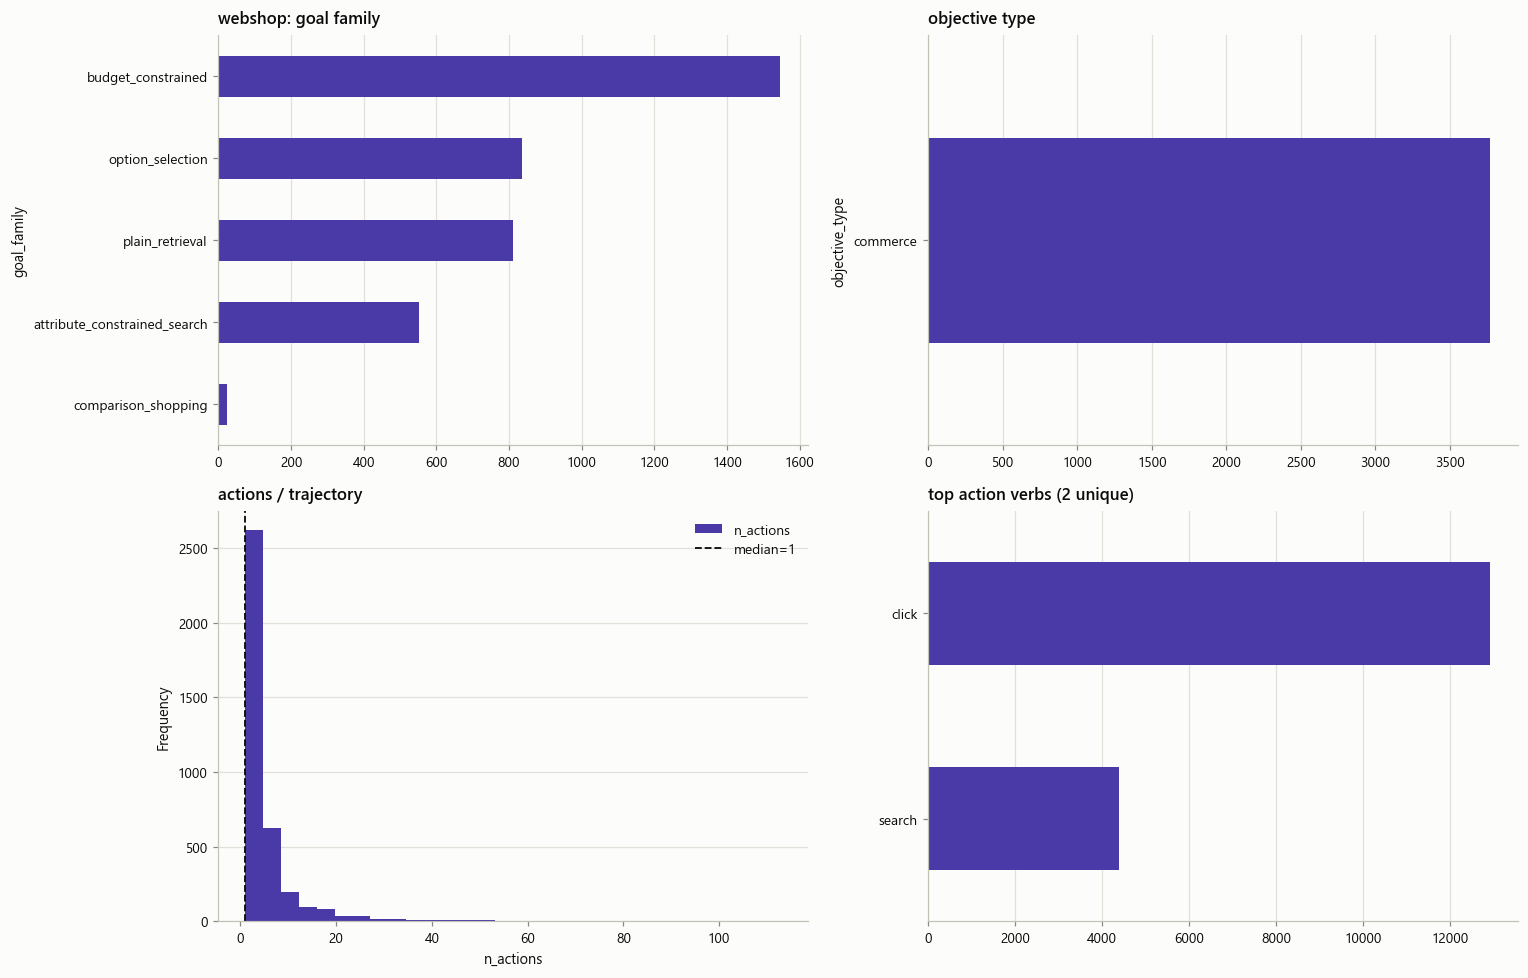

,count,median,mean,max
objective_type,,,,
commerce,3768,1.0,4.6,113


source formats: {'goal_query_map': np.int64(2197), 'full_click_log': np.int64(1571)}


,count,median,mean,max
fmt,,,,
full_click_log,1571,6.0,9.6,113
goal_query_map,2197,1.0,1.0,1


action funnel: {'search': 4394, 'click': 12914}
goal-family mix: {'budget_constrained': np.int64(1546), 'option_selection': np.int64(836), 'plain_retrieval': np.int64(811), 'attribute_constrained_search': np.int64(552), 'comparison_shopping': np.int64(23)}
[webshop] id=webshop-fdb16b008797  split=train  schema=blocks
GOAL: i need a high speed usb flash drive that is 32 gb, and price lower than 50.00 dollars
------------------------------------------------------------------------------------------
  ACTION: search[32 gb high speed usb flash drive ]
  OBS   : Amazon Shopping Game Instruction:   [button] Search [button_]
  ACTION: click[b085x5548b]
  OBS   : Instruction:  [button] Back to Search [button_] Page 1 (Total results: 50) [button] Next > [button_] [button] B0845XPB49 [button_] SanDisk 32GB Ultra 
  ACTION: click[features]
  OBS   : Instruction:  [button] Back to Search [button_] [button] < Prev [button_] V7 32GB USB 3.1 Flash Drive - 32 GB - USB 3.1-120 MB/s Read Speed - Black P

In [37]:
ws = profile_env("webshop", loaded["webshop"])
if ws is not None:
    ws2 = ws.assign(fmt=ws["source_format"].fillna("full_click_log"))
    print("source formats:", dict(ws2["fmt"].value_counts()))
    display(ws2.groupby("fmt")["n_actions"].agg(["count", "median", "mean", "max"]).round(1))
    funnel = Counter(action_verb(a, "webshop") for r in loaded["webshop"] for a in r["actions"])
    print("action funnel:", dict(funnel))
    print("goal-family mix:", dict(ws["goal_family"].value_counts()))
    by_id = {r["trajectory_id"]: r for r in loaded["webshop"]}
    full = ws[ws["n_actions"] > 3]                      # show a real click-through, not a 1-shot query
    ex = full.iloc[0] if len(full) else ws.iloc[0]
    render(by_id[ex["trajectory_id"]])

## 7. Cross-environment taxonomy summary

In [38]:
summary = pd.DataFrame([summary_row("scienceworld", sw, loaded["scienceworld"]),
                        summary_row("alfworld", af, loaded["alfworld"]),
                        summary_row("webshop", ws, loaded["webshop"])]).set_index("env")
summary

,status,n_traj,goal_families,objective_types,median_actions,dominant_interaction,top_verb
env,,,,,,,
scienceworld,empirical,1483,16,"classification, comparison, measurement, multi...",7,directed,look around
alfworld,empirical,7080,7,"examine, manipulation",7,directed,gotolocation
webshop,empirical,3768,5,commerce,1,directed,click


In [39]:
from scripts.transform import granular_metrics as gm
gm_df = pd.DataFrame(gm.trajectory_metrics(r) for env in ENVS for r in loaded[env])
print(f'per-trajectory metrics: {len(gm_df)} rows x {gm_df.shape[1]} features')

key = ['goal_words','n_blocks','n_actions','n_observations','n_thinks',
       'avg_action_words','avg_obs_words','avg_think_words','traj_words',
       'repeated_actions_total','nav_ratio','manip_ratio','think_ratio']
display(gm_df.groupby('env')[key].mean().round(2).T)
display(gm_df.groupby('env')['traj_words'].describe(percentiles=[.1,.5,.9])[['count','10%','50%','90%','max']].round(0))

per-trajectory metrics: 12331 rows x 32 features


env,alfworld,scienceworld,webshop
goal_words,9.30,37.72,16.90
n_blocks,16.16,40.22,10.19
n_actions,7.50,13.41,4.59
n_observations,1.00,12.41,4.59
n_thinks,6.66,13.41,0.00
avg_action_words,2.05,3.94,4.84
avg_obs_words,554.58,40.39,60.50
avg_think_words,11.51,26.66,0.00
traj_words,655.44,825.87,639.66
repeated_actions_total,0.92,5.08,1.14


,count,10%,50%,90%,max
env,,,,,
alfworld,7080.0,375.0,689.0,934.0,1191.0
scienceworld,1483.0,350.0,602.0,1350.0,3717.0
webshop,3768.0,19.0,31.0,1654.0,18391.0


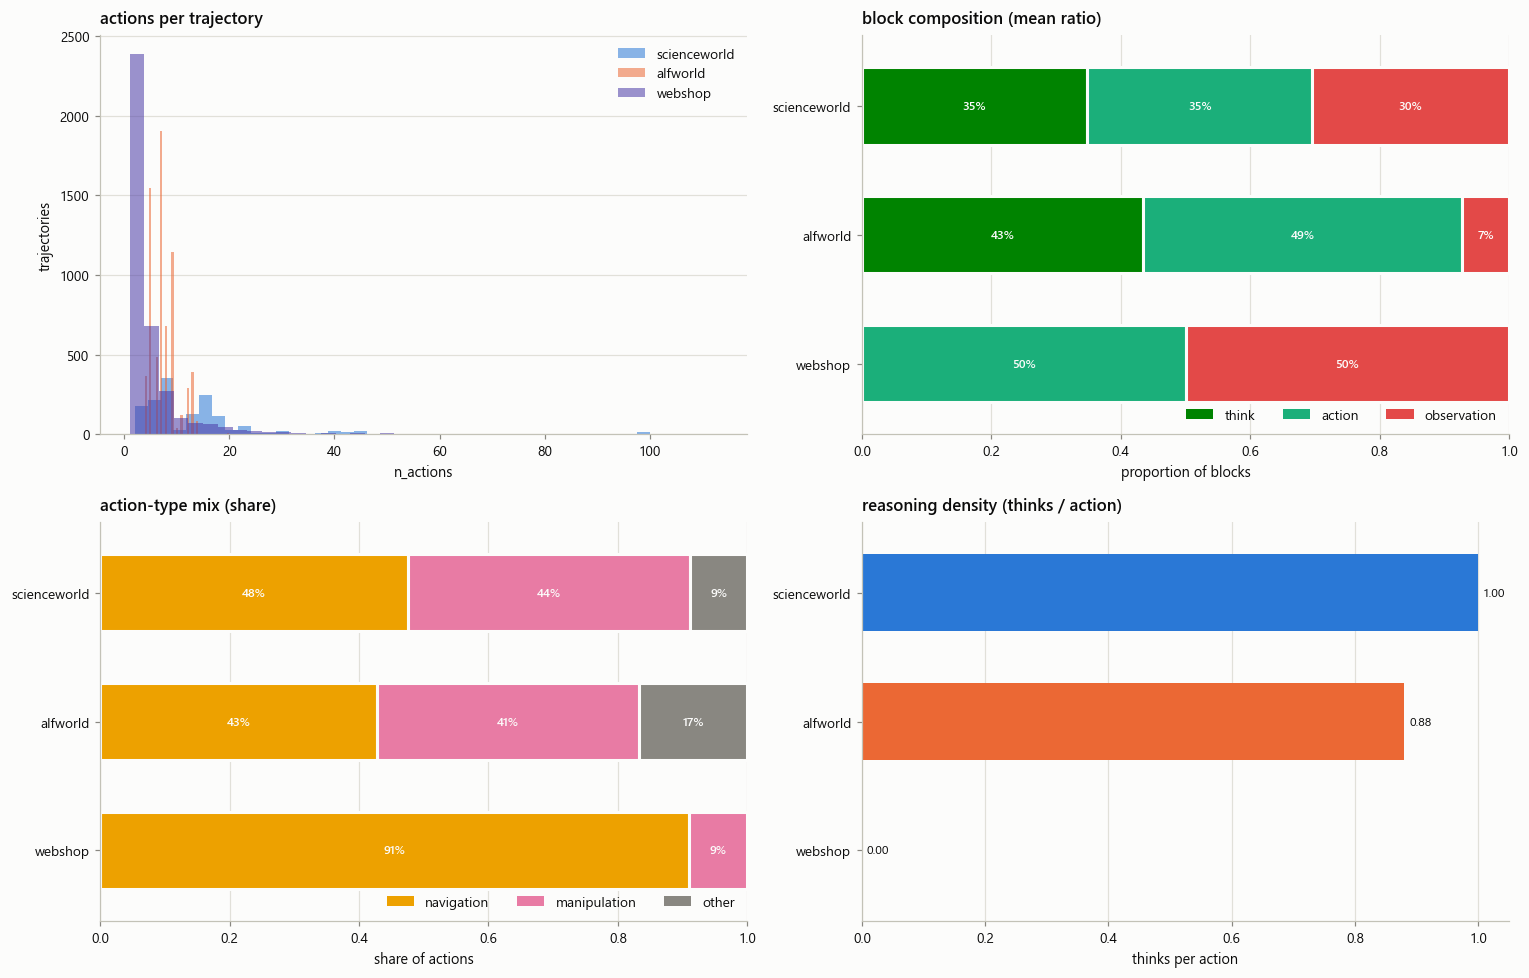

In [40]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

# --- actions per trajectory: three series, coloured by environment
for env in ENVS:
    gm_df[gm_df.env == env]["n_actions"].plot.hist(
        bins=40, alpha=0.55, ax=ax[0, 0], label=env, color=pt.env_color(env))
ax[0, 0].set_title("actions per trajectory")
ax[0, 0].set_xlabel("n_actions"); ax[0, 0].set_ylabel("trajectories")
ax[0, 0].legend(); pt.style_axes(ax[0, 0])

# --- block composition: think / action / observation share of every block
gm_df["block_total"] = gm_df["n_thinks"] + gm_df["n_actions"] + gm_df["n_observations"]
gm_df["think_ratio"] = gm_df["n_thinks"] / gm_df["block_total"].clip(lower=1)
gm_df["action_ratio"] = gm_df["n_actions"] / gm_df["block_total"].clip(lower=1)
gm_df["obs_ratio"] = gm_df["n_observations"] / gm_df["block_total"].clip(lower=1)

comp = gm_df.groupby("env")[["think_ratio", "action_ratio", "obs_ratio"]].mean().loc[ENVS]
comp.plot.barh(stacked=True, ax=ax[0, 1], width=0.6, legend=False,
               color=[pt.BLOCK_COLORS[k] for k in ("think", "action", "observation")])
ax[0, 1].set_title("block composition (mean ratio)")
ax[0, 1].set_xlim(0, 1); ax[0, 1].set_xlabel("proportion of blocks"); ax[0, 1].set_ylabel("")
ax[0, 1].legend(["think", "action", "observation"], loc="lower right", ncols=3)
ax[0, 1].invert_yaxis()          # same env order as ENVS / the legend, top-to-bottom
pt.separate_segments(ax[0, 1]); pt.label_stacked(ax[0, 1]); pt.style_axes(ax[0, 1], xgrid=True)

# --- action-type mix
mix = gm_df.groupby("env")[["n_navigation", "n_manipulation", "n_other_actions"]].sum().loc[ENVS]
mix = mix.div(mix.sum(axis=1), axis=0)
mix.plot.barh(stacked=True, ax=ax[1, 0], width=0.6, legend=False,
              color=[pt.MIX_COLORS[k] for k in ("navigation", "manipulation", "other")])
ax[1, 0].set_title("action-type mix (share)")
ax[1, 0].set_xlim(0, 1); ax[1, 0].set_xlabel("share of actions"); ax[1, 0].set_ylabel("")
ax[1, 0].legend(["navigation", "manipulation", "other"], loc="lower right", ncols=3)
ax[1, 0].invert_yaxis()
pt.separate_segments(ax[1, 0]); pt.label_stacked(ax[1, 0]); pt.style_axes(ax[1, 0], xgrid=True)

# --- reasoning density: one bar per environment, so colour by environment
tpa = (gm_df.assign(tpa=gm_df.n_thinks / gm_df.n_actions.clip(lower=1))
            .groupby("env")["tpa"].mean().loc[ENVS])
tpa.plot.barh(ax=ax[1, 1], width=0.6)
pt.color_env_bars(ax[1, 1], tpa.index)
ax[1, 1].bar_label(ax[1, 1].containers[0], fmt="%.2f", padding=3, color=pt.INK, fontsize=8)
ax[1, 1].set_title("reasoning density (thinks / action)")
ax[1, 1].set_xlabel("thinks per action"); ax[1, 1].set_ylabel("")
ax[1, 1].invert_yaxis()
pt.style_axes(ax[1, 1], xgrid=True)

plt.tight_layout(); plt.show()

### 7.1 Cross-environment leakage / OOD

Extends the ScienceWorld template-leakage finding to all three environments via a per-env
**task-instance key** — ScienceWorld: goal template; ALFWorld: the exact ALFRED
`(task_type, object/parent/recep/toggle)` tuple; WebShop: normalized instruction. `seen_pct` =
share of eval trajectories whose instance already appears in train (memorization-friendly);
`ood_pct` = genuinely unseen task instances.

In [41]:
leak = pd.DataFrame(gm.split_risk_rows(loaded))
display(leak)
print('exact_seen = identical trajectory in train; template_seen = same task instance;')
print('family_seen = unseen instance but seen goal family; strong_ood = unseen family.')

,env,split,n,exact_seen,template_seen,family_seen,strong_ood,seen_pct,ood_pct
0,scienceworld,validation,148,0,146,2,0,98.6,0.0
1,scienceworld,test,148,0,147,1,0,99.3,0.0
2,alfworld,validation,251,0,251,0,0,100.0,0.0
3,alfworld,test,255,0,225,30,0,88.2,0.0
4,webshop,validation,377,12,91,274,0,27.3,0.0
5,webshop,test,377,9,104,264,0,30.0,0.0


exact_seen = identical trajectory in train; template_seen = same task instance;
family_seen = unseen instance but seen goal family; strong_ood = unseen family.


### 7.2 Duplication & repeated behavioural patterns

Exact-trajectory and action-skeleton duplicate clusters per environment, plus the most common
action-verb trigrams (the repeated behavioural motifs a model can latch onto).

In [42]:
display(pd.DataFrame({env: gm.cluster_summary(loaded[env]) for env in ENVS}))
for env in ENVS:
    print()
    print(f'[{env}] top action-verb trigrams:')
    for pat, c in gm.top_action_ngrams(loaded[env], env, k=3, top=5):
        print(f'   {c:6d}  {pat}')

,scienceworld,alfworld,webshop
n_trajectories,1483,7080,3768
unique_full,1483,7080,3708
exact_dup_trajectories,0,0,116
exact_dup_clusters,0,0,56
unique_action_skeletons,1070,3743,3702
skeleton_dup_trajectories,585,4708,127
largest_skeleton_cluster,19,43,3
unique_instance_keys,115,869,3022
largest_instance_cluster,106,65,13



[scienceworld] top action-verb trigrams:
     1114  look around  ->  teleport to  ->  look around
      992  connect  ->  connect  ->  connect
      990  look at  ->  examine  ->  use
      870  examine  ->  use  ->  look at
      870  use  ->  look at  ->  examine

[alfworld] top action-verb trigrams:
     8784  gotolocation  ->  pickupobject  ->  gotolocation
     5418  pickupobject  ->  gotolocation  ->  putobject
     5044  gotolocation  ->  putobject  ->  noop
     1937  putobject  ->  gotolocation  ->  pickupobject
     1931  gotolocation  ->  putobject  ->  gotolocation

[webshop] top action-verb trigrams:
     8707  click  ->  click  ->  click
     2010  search  ->  click  ->  click
      626  click  ->  search  ->  click
      439  click  ->  click  ->  search
      187  search  ->  click  ->  search


### 7.3 Split-overlap matrix

Shared-key counts between splits within each environment — the audit report's overlap table,
generalized to all three envs via the per-env instance key. `shared_instance` = same task
instance across splits; `shared_full_traj` = byte-identical trajectory; `shared_skeleton` =
identical action sequence.

In [43]:
ov = pd.concat({env: pd.DataFrame(gm.overlap_matrix(loaded[env])) for env in ENVS},
               names=['env']).droplevel(1)
display(ov)

,pair,n_right,shared_full_traj,shared_skeleton,shared_instance,shared_family
env,,,,,,
scienceworld,train->validation,148,0,43,48,16
scienceworld,train->test,148,0,49,52,15
scienceworld,validation->test,148,0,17,34,15
alfworld,train->validation,251,0,154,193,7
alfworld,train->test,255,0,93,74,7
alfworld,validation->test,255,0,16,35,7
webshop,train->validation,377,12,12,92,5
webshop,train->test,377,9,11,103,5
webshop,validation->test,377,2,2,30,5


### 7.4 Alternative benchmarks: current vs IID vs grouped-OOD

Validation risk-tier distribution under three split protocols, built live per environment:
**current** (as shipped), **IID-balanced** (group near-duplicate action skeletons so they can't
cross splits), and **grouped-OOD** (group by task instance so no template crosses).
`seen_pct` = exact+template overlap with train.

In [44]:
proto = pd.concat({env: pd.DataFrame(gm.protocol_comparison(loaded[env])) for env in ENVS},
                  names=['env']).droplevel(1)
display(proto)

,protocol,val_n,exact_seen,template_seen,family_seen,strong_ood,seen_pct
env,,,,,,,
scienceworld,current,148,0,146,2,0,98.6
scienceworld,iid_balanced,148,0,141,7,0,95.3
scienceworld,grouped_ood,148,0,0,148,0,0.0
alfworld,current,251,0,251,0,0,100.0
alfworld,iid_balanced,251,0,249,2,0,99.2
alfworld,grouped_ood,251,0,0,251,0,0.0
webshop,current,377,12,91,274,0,27.3
webshop,iid_balanced,377,0,93,284,0,24.7
webshop,grouped_ood,377,0,0,377,0,0.0


**Reading:** IID-balanced barely moves `seen_pct` (it only removes duplicate skeletons, not shared
templates), whereas **grouped-OOD drives `seen_pct` to 0% in all three environments** — it is the
only protocol that actually withholds task instances. This is the concrete justification for using
a grouped-OOD split as the headline validation benchmark.

### 7.5 Per-family leakage

Which goal families leak worst: the template-seen rate of each family's *as-shipped* validation rows.

In [45]:
for env in ['scienceworld', 'alfworld', 'webshop']:
    print(f'[{env}] per-family validation template-seen rate:')
    display(pd.DataFrame(gm.family_leakage(loaded[env])))

[scienceworld] per-family validation template-seen rate:


,goal_family,val,template_seen,seen_pct
0,conductivity,23,23,100.0
1,find_living,15,15,100.0
2,find_animal,14,14,100.0
3,find_plant,12,12,100.0
4,lifespan_longest,11,11,100.0
5,lifespan_shortest,11,11,100.0
6,plant_reproduction,10,10,100.0
7,temperature_measurement,10,10,100.0
8,find_nonliving,8,8,100.0
9,melting_point,8,8,100.0


[alfworld] per-family validation template-seen rate:


,goal_family,val,template_seen,seen_pct
0,pick_and_place_simple,46,46,100.0
1,pick_cool_then_place_in_recep,38,38,100.0
2,pick_clean_then_place_in_recep,37,37,100.0
3,pick_and_place_with_movable_recep,34,34,100.0
4,pick_heat_then_place_in_recep,34,34,100.0
5,pick_two_obj_and_place,33,33,100.0
6,look_at_obj_in_light,29,29,100.0


[webshop] per-family validation template-seen rate:


,goal_family,val,template_seen,seen_pct
0,budget_constrained,156,6,3.8
1,plain_retrieval,86,38,44.2
2,option_selection,78,30,38.5
3,attribute_constrained_search,53,25,47.2
4,comparison_shopping,4,4,100.0


### 7.6 Within-environment difficulty slices

How structure varies inside each environment: ScienceWorld interaction pattern × goal family;
ALFWorld precondition-stateful (clean/cool/heat before place) vs simple; WebShop single-query
logs vs full click-throughs.

In [46]:
swm = gm_df[gm_df.env == 'scienceworld'].copy()
print('ScienceWorld: interaction pattern by objective type')
display(pd.crosstab(swm['interaction_pattern'], swm['objective_type'] if 'objective_type' in swm else swm['goal_family']))

alm = gm_df[gm_df.env == 'alfworld'].copy()
alm['stateful'] = alm['goal_family'].isin(['pick_clean_then_place_in_recep',
    'pick_cool_then_place_in_recep', 'pick_heat_then_place_in_recep'])
print('ALFWorld: precondition-stateful vs simple (means)')
display(alm.groupby('stateful')[['n_actions', 'n_manipulation', 'n_navigation']].mean().round(2))

wsm = gm_df[gm_df.env == 'webshop'].copy()
wsm['fmt'] = wsm['source_format'].fillna('full_click_log')
print('WebShop: query-only logs vs full click-throughs')
display(wsm.groupby('fmt')[['n_actions', 'n_navigation', 'nav_ratio', 'traj_words']].agg(['count', 'median', 'mean']).round(2))

ScienceWorld: interaction pattern by objective type


goal_family,change_state_of_matter,chemistry_mixing,conductivity,find_animal,find_living,find_nonliving,find_plant,focus_lifestage,lifespan_dual,lifespan_longest,lifespan_shortest,melting_point,plant_growth,plant_reproduction,power_device,temperature_measurement
interaction_pattern,,,,,,,,,,,,,,,,
directed,27,49,237,120,120,0,120,0,6,0,0,91,0,0,16,0
repair_or_disambiguation,0,0,3,0,0,0,0,0,0,0,0,0,83,62,0,0
repetitive,14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
search_heavy,3,3,0,0,0,120,0,2,72,83,83,29,0,0,0,120
stateful_waiting,12,0,0,0,0,0,0,8,0,0,0,0,0,0,0,0


ALFWorld: precondition-stateful vs simple (means)


,n_actions,n_manipulation,n_navigation
stateful,,,
False,7.02,3.22,2.90
True,8.17,2.79,3.62


WebShop: query-only logs vs full click-throughs


n_actions              n_navigation              nav_ratio              traj_words                
                   count median  mean        count median  mean     count median  mean      count median     mean
fmt                                                                                                              
full_click_log      1571    6.0  9.62         1571    5.0  8.62      1571   0.83  0.83       1571  825.0  1499.24
goal_query_map      2197    1.0  1.00         2197    1.0  1.00      2197   1.00  1.00       2197   24.0    25.00

### 7.7 Token-length distributions across granularities

The same metric — **token length** — measured at every granularity and compared across the
three datasets on shared axes: per `goal`, per `action`, per `observation`, per `thought`, per
whole `trajectory`, and pooled per `block` (any event). Tokens are counted with the `tiktoken`
cl100k BPE tokenizer (a consistent subword proxy for the model tokenizer; falls back to
whitespace words if unavailable).

In [47]:
# Token length measured at every granularity, for all three datasets.
# tiktoken cl100k is a consistent subword proxy for the model tokenizer; if it is not
# installed we fall back to whitespace words (same schema, coarser unit).
try:
    import tiktoken
    _enc = tiktoken.get_encoding("cl100k_base")
    tokenize, TOK = (lambda t: len(_enc.encode(str(t)))), "tiktoken cl100k_base"
except Exception as e:                                  # noqa: BLE001 - optional dep
    tokenize, TOK = gm.word_tokens, f"whitespace words (no tiktoken: {type(e).__name__})"

len_df = pd.DataFrame(gm.unit_lengths(
    [r for env in ENVS for r in loaded[env]], tok=tokenize))
print(f"tokenizer: {TOK} | {len(len_df):,} measured text units")

display(len_df.pivot_table(index="granularity", columns="env", values="tokens", aggfunc="median")
              .reindex(["goal", "action", "observation", "thought", "trajectory"])[ENVS]
              .rename_axis("median tokens"))

tokenizer: tiktoken cl100k_base | 224,765 measured text units


env,scienceworld,alfworld,webshop
median tokens,,,
goal,42.0,10.0,20.0
action,4.0,4.0,6.0
observation,11.0,2739.5,200.0
thought,24.0,11.0,NaN
trajectory,751.0,2871.5,44.0


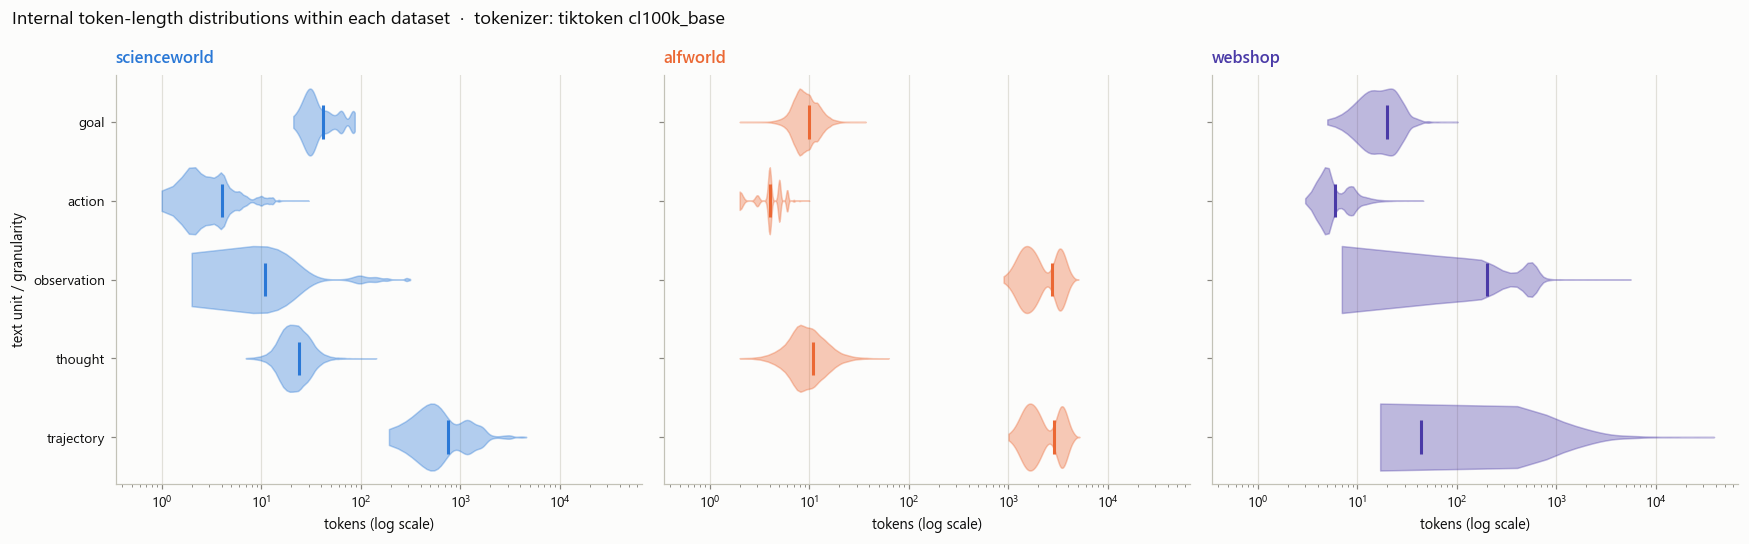

In [48]:
order = ["goal", "action", "observation", "thought", "trajectory"]
y_positions = list(range(1, len(order) + 1))

# sharey: every panel has the same granularity rows, so the row labels are drawn ONCE
# on the left-hand panel; sharex puts all three datasets on one comparable token scale.
fig, axes = plt.subplots(1, len(ENVS), figsize=(16, 5), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, env in zip(axes, ENVS):
    color = pt.env_color(env)
    env_df = len_df[len_df["env"] == env]

    data, positions = [], []
    for pos, gran in zip(y_positions, order):
        vals = env_df.loc[env_df["granularity"] == gran, "tokens"].dropna().to_numpy()
        vals = vals[vals > 0]                    # log axis: empty units carry no length
        if len(vals):
            data.append(vals)
            positions.append(pos)

    ax.set_title(env, color=color)
    ax.set_xlabel("tokens (log scale)")

    if not data:
        ax.text(0.5, 0.5, "no data", transform=ax.transAxes,
                ha="center", va="center", color=pt.INK_MUTED)
        continue

    parts = ax.violinplot(data, positions=positions, vert=False, widths=0.85,
                          showmeans=False, showmedians=True, showextrema=False)
    for body in parts["bodies"]:
        body.set_facecolor(color); body.set_edgecolor(color)
        body.set_alpha(0.35); body.set_linewidth(1.0)
    parts["cmedians"].set_color(color); parts["cmedians"].set_linewidth(2)

    ax.set_xscale("log")
    pt.style_axes(ax, xgrid=True)

# shared y: label once, on the left; sharey hides the duplicates on the other panels
axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(order)
axes[0].set_ylim(0.4, len(order) + 0.6)
axes[0].invert_yaxis()                            # goal at the top, whole trajectory at the bottom
axes[0].set_ylabel("text unit / granularity")

fig.suptitle(f"Internal token-length distributions within each dataset  ·  tokenizer: {TOK}",
             x=0.01, ha="left")
fig.tight_layout()
plt.show()

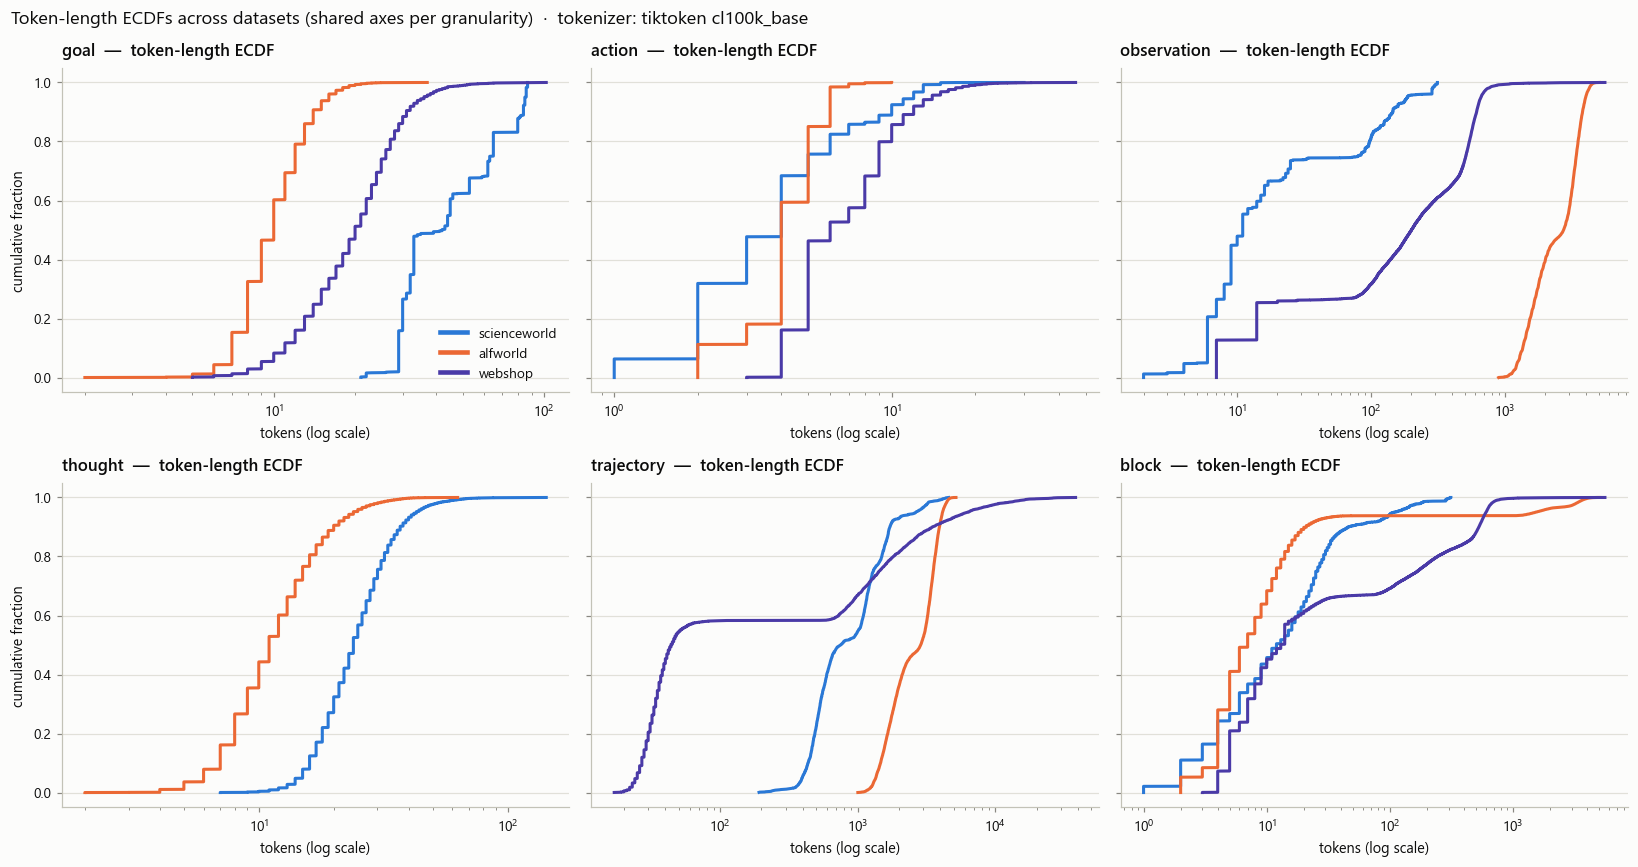

In [49]:
grans = ["goal", "action", "observation", "thought", "trajectory", "block"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)

for ax, g in zip(axes.ravel(), grans):
    sub = len_df[len_df.granularity != "trajectory"] if g == "block" else len_df[len_df.granularity == g]
    for env in ENVS:
        pt.ecdf(ax, sub[sub.env == env]["tokens"], env, pt.env_color(env))   # ECDF helper -> plot_theme
    ax.set_xscale("log")
    ax.set_title(f"{g}  —  token-length ECDF")
    ax.set_xlabel("tokens (log scale)")
    pt.style_axes(ax)

for ax in axes[:, 0]:                    # sharey: one y-label per row, no repeated ticks
    ax.set_ylabel("cumulative fraction")
pt.env_legend(axes[0, 0], ENVS, loc="lower right")

fig.suptitle(f"Token-length ECDFs across datasets (shared axes per granularity)  ·  tokenizer: {TOK}",
             x=0.01, ha="left")
fig.tight_layout()
plt.show()

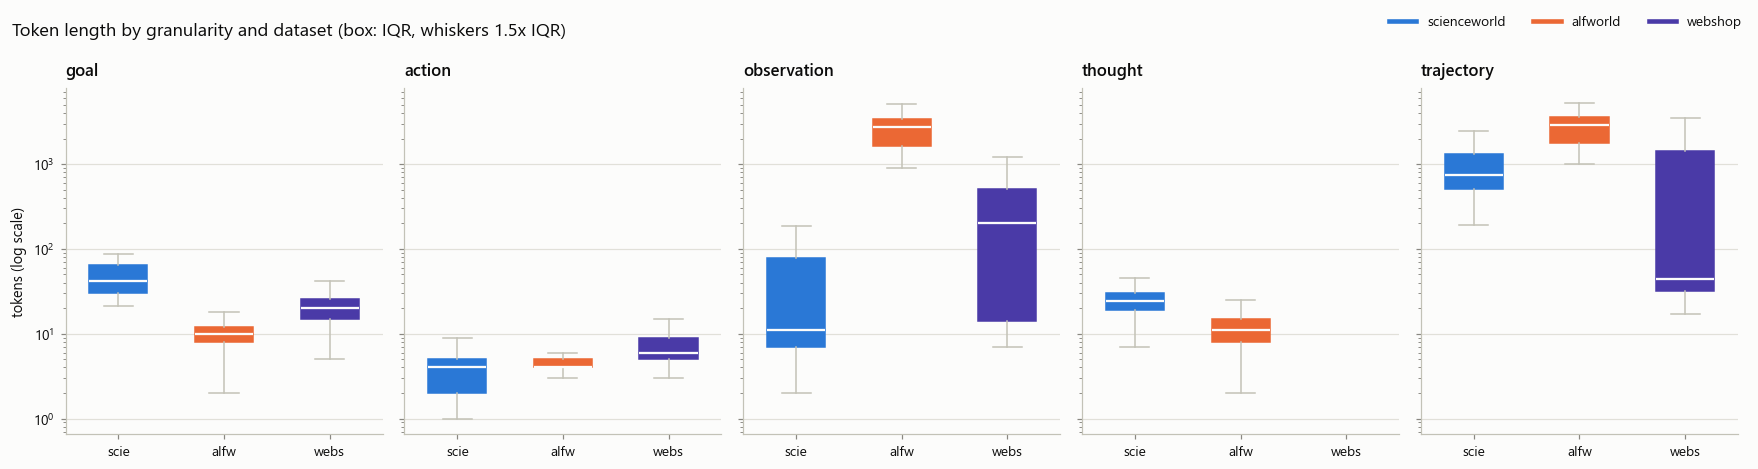

In [50]:
fig, axes = plt.subplots(1, len(order), figsize=(16, 4.2), sharey=True)

for ax, g in zip(axes, order):
    sub = len_df[len_df.granularity == g]
    data = [sub.loc[sub.env == e, "tokens"].to_numpy() for e in ENVS]
    bp = ax.boxplot(data, tick_labels=[e[:4] for e in ENVS], showfliers=False, widths=0.55,
                    patch_artist=True,
                    medianprops=dict(color=pt.SURFACE, linewidth=1.5),
                    whiskerprops=dict(color=pt.BASELINE),
                    capprops=dict(color=pt.BASELINE))
    for patch, env in zip(bp["boxes"], ENVS):
        patch.set_facecolor(pt.env_color(env))
        patch.set_edgecolor(pt.env_color(env))
    ax.set_yscale("log")
    ax.set_title(g)
    pt.style_axes(ax)

axes[0].set_ylabel("tokens (log scale)")   # sharey: one y-label, ticks only on the left
handles = [plt.Line2D([], [], color=pt.env_color(e), lw=3, label=e) for e in ENVS]
fig.legend(handles=handles, loc="upper right", ncols=3, bbox_to_anchor=(1, 1.02))

fig.suptitle("Token length by granularity and dataset (box: IQR, whiskers 1.5x IQR)",
             x=0.01, ha="left")
fig.tight_layout()
plt.show()

### 7.8 Interpretation

- **Every shipped split is memorization-friendly.** Current-split validation is 98.6% (ScienceWorld),
  100% (ALFWorld), and 27.3% (WebShop) exact-or-template seen, and **none** of the three has a single
  strong-OOD (unseen-family) eval trajectory. ALFWorld is the most leaked: *every* validation family
  is 100% template-seen.
- **The leakage is structural, not duplication.** There are ~0 byte-identical train→val trajectories;
  the overlap is at the task-instance / template level (shared_instance ≫ shared_full_traj).
- **Grouped-OOD fixes it and IID does not.** Grouping by task instance takes `seen_pct` to 0% in all
  three envs; grouping only near-duplicate skeletons (IID) leaves it near the current level.
- **Structure differs sharply across envs** and maps onto what a model can shortcut: WebShop is a
  reasoning-free navigation funnel (0 thinks, 93% nav), ALFWorld is short precondition-stateful
  plans with 66% duplicated action skeletons, ScienceWorld is the most reasoning- and
  manipulation-balanced. These are the slices on which D-Random (memorization) and D-Flex
  (structure) should diverge.

## 8. Takeaways

All three environments share the same `blocks` event schema (`Goal/Think/Action/
Observation`), so one canonical loader + taxonomy covers them — only the goal-family
and action vocabularies differ. What the three *kinds* of trajectory look like:

- **ScienceWorld** — narrow, heavily-templated goal families (conductivity, find-a-thing,
  temperature/melting-point measurement, lifespan comparison, plant growth) collapsing
  to ~6 objective types; short-to-medium trajectories; `teleport`/`look around`
  navigation with real disambiguation/repair loops. This templating is the root of the
  memorization concern in the split audit.
- **ALFWorld** — 7 exact ALFRED task types (well balanced), roughly a third of them
  **precondition-stateful** (must clean/cool/heat *before* placing). Short PDDL-operator
  plans (`GotoLocation → PickupObject → PutObject`), offline plan-only (≈1 observation).
  The stateful ordering is genuine causal structure a template-matcher can't shortcut.
- **WebShop** — a `search → click` purchase funnel. Two populations: single-query
  `goal_query_map` logs vs full click-throughs (long tail to ~100+ actions). Commerce
  objective with attribute/budget/option-constrained instructions.

**Why it matters for AOMT:** these axes are the slices that separate *memorization*
from *representation learning*. Narrow templated ScienceWorld families are where
D-Random can memorize; the cross-family / cross-environment axes — ALFWorld's stateful
preconditions and WebShop's long interactive funnels — are where D-Flex's structured
objectives should show their advantage. This taxonomy is the slice framework for that
comparison.